In [23]:
import pandas as pd
import re

In [24]:
import pandas as pd

df1 = pd.read_excel("/LPG_Crisis_Comments_Cleaned.xlsx")
df2 = pd.read_excel("/comments.xlsx")
df3 = pd.read_excel("/comments2.xlsx")
df4 = pd.read_csv("/raw_instagram1.csv")
df5 = pd.read_csv("/raw_instagram2.csv")
df6 = pd.read_csv("/tweets_lpg_crisis (1).csv")
df7 = pd.read_csv("/instagram_1 (1).csv")
df8 = pd.read_csv("/instagram_2.csv")

In [25]:
def standardize(df):
    df.columns = df.columns.str.lower().str.strip()
    return df

df1,df2,df3,df4,df5,df6,df7,df8 = [standardize(d) for d in [df1,df2,df3,df4,df5,df6,df7,df8]]

In [26]:
def merge_hashtag_cols(df):
    # Catches hashtags/0, hashtags/1 ... hashtags/12 format
    hashtag_cols = [c for c in df.columns if re.match(r'hashtags?/\d+', c.lower())]

    if hashtag_cols:
        def combine_row(row):
            tags = []
            for col in hashtag_cols:
                val = str(row[col]).strip().lower()
                if val and val not in ['nan', 'none', '']:
                    if not val.startswith('#'):
                        val = '#' + val
                    tags.append(val)
            return ', '.join(sorted(set(tags))) if tags else 'none'

        df['hashtags_from_cols'] = df.apply(combine_row, axis=1)
        print(f"  Found: {hashtag_cols}")
    else:
        df['hashtags_from_cols'] = 'none'

    return df

print("Hashtag columns found per file:")
for name, df in [("df1",df1),("df2",df2),("df3",df3),("df4",df4),
                  ("df5",df5),("df6",df6),("df7",df7),("df8",df8)]:
    print(f"\n{name}:")
    df = merge_hashtag_cols(df)

df1,df2,df3,df4,df5,df6,df7,df8 = [merge_hashtag_cols(d) for d in
                                     [df1,df2,df3,df4,df5,df6,df7,df8]]

Hashtag columns found per file:

df1:

df2:

df3:

df4:
  Found: ['hashtags/0', 'hashtags/1', 'hashtags/2', 'hashtags/3', 'hashtags/4', 'hashtags/5', 'hashtags/6', 'hashtags/7', 'hashtags/8', 'hashtags/9', 'hashtags/10', 'hashtags/11', 'hashtags/12', 'hashtags/13', 'hashtags/14', 'hashtags/15', 'hashtags/16', 'hashtags/17', 'hashtags/18', 'hashtags/19', 'hashtags/20']

df5:
  Found: ['hashtags/0', 'hashtags/1', 'hashtags/2', 'hashtags/3', 'hashtags/4', 'hashtags/5', 'hashtags/6', 'hashtags/7', 'hashtags/8', 'hashtags/9', 'hashtags/10', 'hashtags/11', 'hashtags/12']

df6:

df7:
  Found: ['hashtags/0', 'hashtags/1', 'hashtags/2', 'hashtags/3', 'hashtags/4', 'hashtags/5', 'hashtags/6', 'hashtags/7', 'hashtags/8', 'hashtags/9', 'hashtags/10', 'hashtags/11', 'hashtags/12', 'hashtags/13', 'hashtags/14', 'hashtags/15', 'hashtags/16', 'hashtags/17', 'hashtags/18', 'hashtags/19', 'hashtags/20', 'hashtags/21', 'hashtags/22']

df8:
  Found: ['hashtags/0', 'hashtags/1', 'hashtags/2', 'hashtags/3',

In [27]:
def parse_time(df):
    df['time'] = pd.to_datetime(df['time'], errors='coerce').dt.date
    return df

df1,df2,df3,df4,df5,df6,df7,df8 = [parse_time(d) for d in [df1,df2,df3,df4,df5,df6,df7,df8]]

In [28]:
def fill_missing(df):
    df['comment'] = df['comment'].fillna("no comment").astype(str).str.strip()
    df['type']    = df['type'].fillna("unknown")
    df            = df[df['time'].notna()]
    return df

df1,df2,df3,df4,df5,df6,df7,df8 = [fill_missing(d) for d in [df1,df2,df3,df4,df5,df6,df7,df8]]

In [29]:
combined = pd.concat([df1,df2,df3,df4,df5,df6,df7,df8], ignore_index=True)

In [30]:
combined['comment'] = combined['comment'].str.lower()
combined['type']    = combined['type'].str.lower()

In [31]:
def extract_hashtags(text):
    tags = re.findall(r'#\w+', str(text))
    return ', '.join(tags) if tags else 'none'

def remove_hashtags(text):
    return re.sub(r'#\w+', '', str(text)).strip()

combined['hashtags_from_text'] = combined['comment'].apply(extract_hashtags)
combined['comment']            = combined['comment'].apply(remove_hashtags)

In [32]:
!pip install deep-translator langdetect -q
from deep_translator import GoogleTranslator
from langdetect import detect
from tqdm import tqdm
import time

def detect_language(text):
    try:
        return detect(str(text))
    except:
        return 'en'

def translate_to_english(text):
    try:
        text = str(text).strip()
        if not text or text == 'no comment':
            return text
        lang = detect_language(text)
        if lang == 'en':
            return text
        time.sleep(0.1)
        translated = GoogleTranslator(source='auto', target='en').translate(text)
        return translated if translated else text
    except:
        return text

tqdm.pandas()
print("Detecting languages...")
combined['detected_lang']    = combined['comment'].apply(detect_language)
print(combined['detected_lang'].value_counts())

print("\nTranslating...")
combined['comment_original'] = combined['comment'].copy()
combined['comment']          = combined['comment'].progress_apply(translate_to_english)

Detecting languages...
detected_lang
en    696
hi     33
ur     33
id     13
bn     12
it     10
te      9
fa      8
fr      7
ta      7
gu      5
et      4
tl      4
tr      4
ml      4
mr      4
nl      4
sq      2
ru      2
sv      2
ne      2
kn      2
he      2
de      2
so      2
lv      1
pt      1
da      1
th      1
cy      1
ja      1
sw      1
es      1
ko      1
ro      1
hr      1
Name: count, dtype: int64

Translating...


100%|██████████| 884/884 [00:38<00:00, 22.80it/s]


In [33]:
!pip install emoji -q
import emoji

combined['comment'] = combined['comment'].apply(lambda x: emoji.replace_emoji(str(x), replace=''))

print("Done!")
print(combined['comment'].head(5))

Done!
0    q : did people have to stand in queue for gas ...
1    india’s lpg crisis is now rewriting menus in r...
2    gas cylinder booked on 31st march which delive...
3    indian woman needed helping hand during lpg cr...
4    domestic supply of lpg is fine but commerciall...
Name: comment, dtype: object


In [34]:
def merge_all_hashtags(row):
    from_text = row.get('hashtags_from_text', 'none')
    from_cols = row.get('hashtags_from_cols', 'none')

    all_tags = set()
    for part in [from_text, from_cols]:
        for tag in str(part).split(','):
            tag = tag.strip().lower()
            if tag and tag not in ['none', 'nan', '']:
                if not tag.startswith('#'):
                    tag = '#' + tag
                all_tags.add(tag)

    return ', '.join(sorted(all_tags)) if all_tags else 'none'

combined['hashtags'] = combined.apply(merge_all_hashtags, axis=1)
combined = combined.drop(columns=['hashtags_from_text', 'hashtags_from_cols'], errors='ignore')


In [35]:
!pip install contractions -q
import re
import contractions
import nltk
nltk.download('stopwords', quiet=True)

def full_clean(text):
    text = str(text)

    # 1. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 2. Remove mentions
    text = re.sub(r'@\w+', '', text)

    # 3. Remove HTML entities (&amp; &lt; &gt; etc)
    text = re.sub(r'&\w+;', '', text)

    # 4. Expand contractions (won't → will not)
    try:
        text = contractions.fix(text)
    except:
        pass

    # 5. Remove special characters
    text = re.sub(r'[^\w\s]', ' ', text)

    # 6. Remove numbers (₹1200, 2024 etc)
    text = re.sub(r'\d+', '', text)

    # 7. Remove repeated characters (sooooo → so)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # 8. Remove underscores leftover from \w cleanup
    text = re.sub(r'_+', ' ', text)

    # 9. Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    return text if text.strip() else 'no comment'

print("Cleaning...")
combined['comment'] = combined['comment'].apply(full_clean)


Cleaning...


In [36]:
before = len(combined)
combined['_dedup_key'] = (combined['comment']
                          .str.replace(r'\s+', ' ', regex=True)
                          .str.replace(r'[^\w\s]', '', regex=True)
                          .str.strip())
combined = combined.drop_duplicates(subset='_dedup_key', keep='first')
combined = combined.drop(columns='_dedup_key')
after = len(combined)

print(f"Rows before : {before}")
print(f"Rows after  : {after}")
print(f"Dropped     : {before - after}")
print(f"\nShape       : {combined.shape}")
print(f"Columns     : {combined.columns.tolist()}")
print(f"\nSample cleaned comments:")
print(combined['comment'].head(10).to_string())
print(f"\nDuplicates removed : {before - after}")

Rows before : 884
Rows after  : 812
Dropped     : 72

Shape       : (812, 52)
Columns     : ['no', 'type', 'time', 'username', 'comment', 'ownerfullname', 'ownerusername', 'url', 'commentscount', 'firstcomment', 'likescount', 'querytag', 'hashtags/0', 'hashtags/1', 'hashtags/2', 'hashtags/3', 'hashtags/4', 'hashtags/5', 'hashtags/6', 'hashtags/7', 'hashtags/8', 'hashtags/9', 'hashtags/10', 'hashtags/11', 'hashtags/12', 'hashtags/13', 'hashtags/14', 'hashtags/15', 'hashtags/16', 'hashtags/17', 'hashtags/18', 'hashtags/19', 'hashtags/20', 'unnamed: 30', 'unnamed: 22', 's.no', 'unnamed: 3', 'unnamed: 4', 'hashtags/21', 'hashtags/22', 'unnamed: 32', 'hashtags/23', 'hashtags/24', 'hashtags/25', 'hashtags/26', 'hashtags/27', 'hashtags/28', 'hashtags/29', 'unnamed: 39', 'detected_lang', 'comment_original', 'hashtags']

Sample cleaned comments:
0    q did people have to stand in queue for gas cy...
1    india s lpg crisis is now rewriting menus in r...
2    gas cylinder booked on st march whic

In [37]:
combined = combined.reset_index(drop=True)
combined['sno'] = range(1, len(combined) + 1)


combined = combined[['sno', 'comment', 'hashtags', 'time', 'type']]

print(f"Total rows: {len(combined)}")
print(combined.head())

Total rows: 812
   sno                                            comment    hashtags  \
0    1  q did people have to stand in queue for gas cy...        none   
1    2  india s lpg crisis is now rewriting menus in r...  #bengaluru   
2    3  gas cylinder booked on st march which delivere...        none   
3    4  indian woman needed helping hand during lpg cr...        none   
4    5  domestic supply of lpg is fine but commerciall...        none   

         time type  
0  2026-05-03    x  
1  2026-05-03    x  
2  2026-05-03    x  
3  2026-05-03    x  
4  2026-04-27    x  


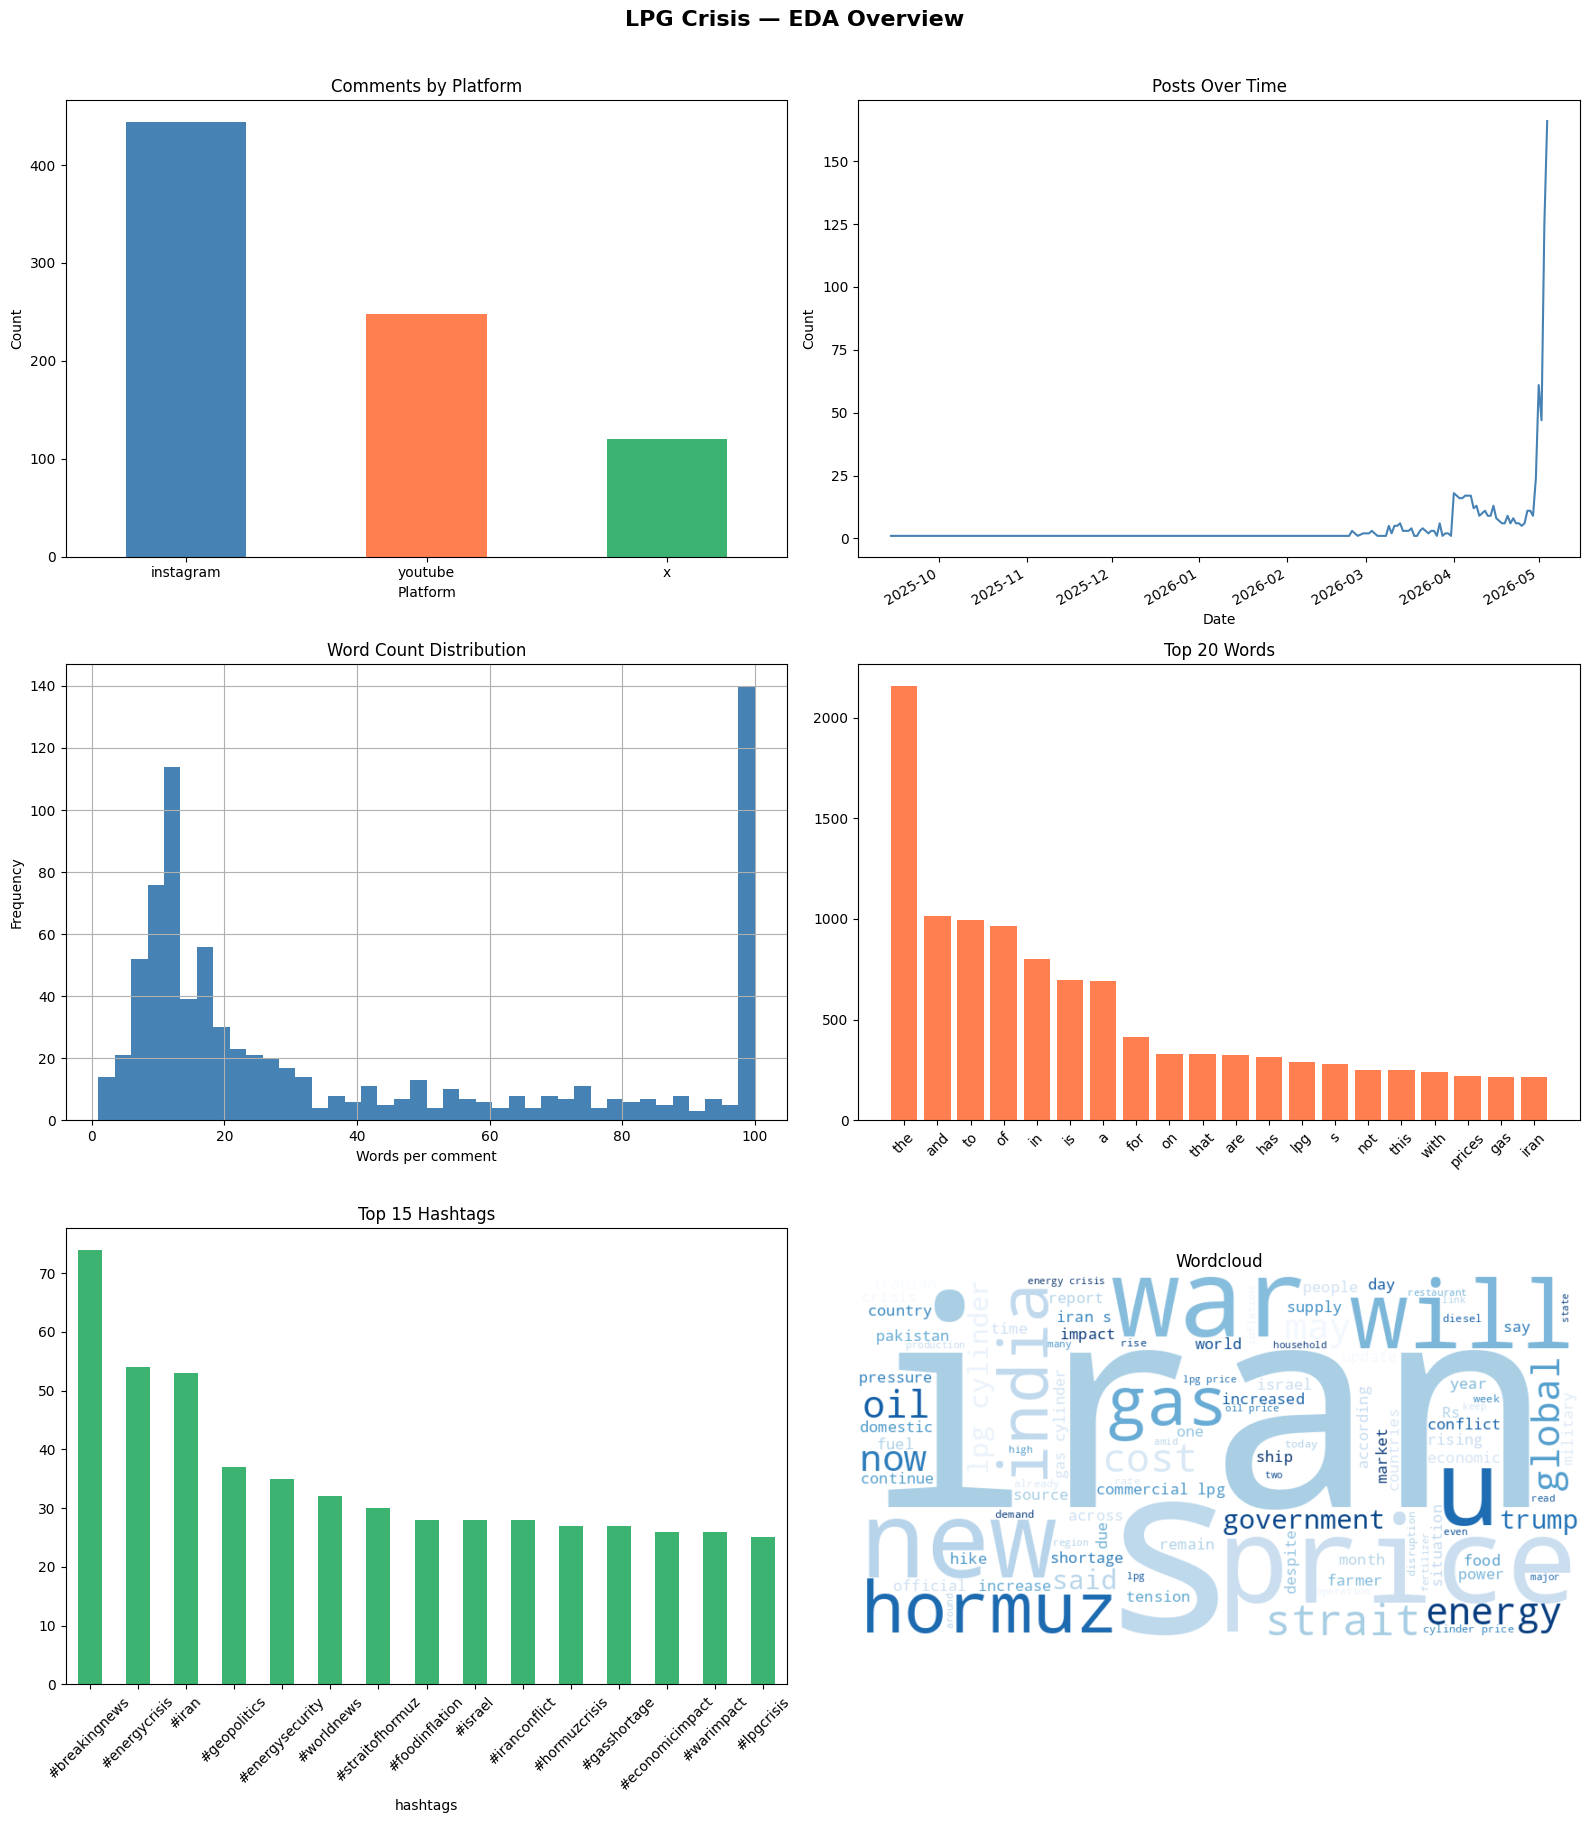

Total comments  : 812
Date range      : 2025-09-14 → 2026-05-04
Avg word count  : 52.1

Platform split:
type
instagram    444
youtube      248
x            120
Name: count, dtype: int64

Top 10 hashtags:
hashtags
#breakingnews      74
#energycrisis      54
#iran              53
#geopolitics       37
#energysecurity    35
#worldnews         32
#straitofhormuz    30
#foodinflation     28
#israel            28
#iranconflict      28
Name: count, dtype: int64


In [38]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

!pip install wordcloud -q

combined['time'] = pd.to_datetime(combined['time'], errors='coerce')
combined['word_count'] = combined['comment'].apply(lambda x: len(str(x).split()))

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('LPG Crisis — EDA Overview', fontsize=16, fontweight='bold', y=1.01)

# ── 1. Platform distribution ──────────────────────────────────────────────────
combined['type'].value_counts().plot(kind='bar', ax=axes[0,0], color=['steelblue','coral','mediumseagreen'])
axes[0,0].set_title('Comments by Platform')
axes[0,0].set_xlabel('Platform')
axes[0,0].set_ylabel('Count')
axes[0,0].tick_params(axis='x', rotation=0)

# ── 2. Posts over time ────────────────────────────────────────────────────────
combined.groupby('time').size().plot(ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Posts Over Time')
axes[0,1].set_xlabel('Date')
axes[0,1].set_ylabel('Count')

# ── 3. Word count distribution ────────────────────────────────────────────────
combined['word_count'].clip(upper=100).hist(bins=40, ax=axes[1,0], color='steelblue')
axes[1,0].set_title('Word Count Distribution')
axes[1,0].set_xlabel('Words per comment')
axes[1,0].set_ylabel('Frequency')

# ── 4. Top 20 words ───────────────────────────────────────────────────────────
all_words  = ' '.join(combined['comment'].dropna()).split()
word_freq  = Counter(all_words).most_common(20)
words, freqs = zip(*word_freq)
axes[1,1].bar(words, freqs, color='coral')
axes[1,1].set_title('Top 20 Words')
axes[1,1].tick_params(axis='x', rotation=45)

# ── 5. Top 15 hashtags ────────────────────────────────────────────────────────
all_tags = combined['hashtags'].str.split(', ').explode()
top_tags  = all_tags[all_tags != 'none'].value_counts().head(15)
top_tags.plot(kind='bar', ax=axes[2,0], color='mediumseagreen')
axes[2,0].set_title('Top 15 Hashtags')
axes[2,0].tick_params(axis='x', rotation=45)

# ── 6. Wordcloud ──────────────────────────────────────────────────────────────
text      = ' '.join(combined['comment'].dropna())
wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='Blues',
                      max_words=100).generate(text)
axes[2,1].imshow(wordcloud, interpolation='bilinear')
axes[2,1].axis('off')
axes[2,1].set_title('Wordcloud')

plt.tight_layout()
plt.savefig('/content/eda_overview.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print(f"Total comments  : {len(combined)}")
print(f"Date range      : {combined['time'].min().date()} → {combined['time'].max().date()}")
print(f"Avg word count  : {combined['word_count'].mean():.1f}")
print(f"\nPlatform split:\n{combined['type'].value_counts()}")
print(f"\nTop 10 hashtags:\n{top_tags.head(10)}")

In [39]:
from collections import Counter
import pandas as pd

all_words = ' '.join(combined['comment'].dropna()).split()
word_freq  = Counter(all_words)

# Keep words appearing 3+ times only (ignore rare words)
freq_words = {w: c for w, c in word_freq.items()
              if c >= 3 and len(w) > 2}

word_df = pd.DataFrame(freq_words.items(), columns=['word', 'frequency'])
word_df = word_df.sort_values('frequency', ascending=False).reset_index(drop=True)

print(f"Total unique words (3+ freq): {len(word_df)}")
print(word_df.head(30))

Total unique words (3+ freq): 2139
          word  frequency
0          the       2157
1          and       1017
2          for        413
3         that        331
4          are        323
5          has        316
6          lpg        289
7         this        251
8          not        251
9         with        241
10      prices        223
11         gas        218
12        iran        214
13      energy        192
14        have        189
15         oil        180
16        from        164
17         war        160
18      global        156
19         you        150
20      crisis        146
21        fuel        143
22       price        138
23        will        138
24      supply        137
25       india        136
26    cylinder        134
27  commercial        125
28        been        119
29        more        106


In [40]:
with pd.ExcelWriter("/content/combined_lpg_data.xlsx", engine='openpyxl') as writer:
    combined.to_excel(writer, index=False, sheet_name='LPG Data')
    ws = writer.sheets['LPG Data']
    for col in ws.columns:
        max_len = max(len(str(col[0].value)),
                      *[len(str(cell.value)) for cell in col[1:]])
        ws.column_dimensions[col[0].column_letter].width = min(max_len + 4, 60)

print("\nSaved to combined_lpg_data.xlsx")


Saved to combined_lpg_data.xlsx
